# Bank Churn — 05: Decision Analysis & Business Proposals

Notebooks 02–04 produced tuned classifiers. This notebook turns the best one
(XGBoost, nb 03: test ROC-AUC 0.8700) into a **decision system**:

1. Calibrate its probabilities (a campaign budget is allocated on probabilities, not ranks)
2. Derive the optimal contact threshold from an explicit cost matrix
3. Stress-test that threshold over the cost assumptions (sensitivity analysis)
4. Translate everything into concrete business proposals with campaign sizing

## 1. Setup, data and the tuned model from notebook 03

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "data/Churn_Modelling.csv"
KAGGLE_DATASET = "shrutimechlearn/churn-modelling"
MIRROR_URL = (
    "https://raw.githubusercontent.com/sharmaroshan/"
    "Churn-Modelling-Dataset/master/Churn_Modelling.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror: {MIRROR_URL}")
    return path


df = pd.read_csv(fetch_data())
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

Found cached file: data/Churn_Modelling.csv


In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


class DomainFeatures(BaseEstimator, TransformerMixin):
    """Adds EDA-motivated features; keeps the DataFrame interface."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["zero_balance"] = (X["Balance"] == 0).astype(int)
        X["balance_salary_ratio"] = X["Balance"] / (X["EstimatedSalary"] + 1.0)
        X["german_balance"] = (X["Geography"] == "Germany") * X["Balance"] / 1e5
        X["products_cat"] = X["NumOfProducts"].astype(str)
        X["inactive_senior"] = ((X["IsActiveMember"] == 0) & (X["Age"] >= 45)).astype(int)
        return X


CATEGORICAL = ["Geography", "Gender", "products_cat"]
NUMERIC = [
    "CreditScore", "Age", "Tenure", "Balance", "HasCrCard",
    "IsActiveMember", "EstimatedSalary", "zero_balance", "balance_salary_ratio",
    "german_balance", "inactive_senior",
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

# Winning configuration from notebook 03 (two-stage search result)
XGB_PARAMS = dict(
    n_estimators=280, learning_rate=0.0543, max_depth=3, min_child_weight=2,
    subsample=0.9906, colsample_bytree=0.9850, gamma=0.00854, reg_lambda=0.458,
    tree_method="hist", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
)
SMOTE_PARAMS = dict(k_neighbors=9, sampling_strategy=0.6, random_state=RANDOM_STATE)

model = ImbPipeline([
    ("domain", DomainFeatures()),
    ("prep", preprocessor),
    ("smote", SMOTE(**SMOTE_PARAMS)),
    ("clf", XGBClassifier(**XGB_PARAMS)),
])

X = df.drop(columns=["Exited"])
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} (churn {y_test.mean():.2%})")

Train: 8000 | Test: 2000 (churn 20.35%)


## 2. Calibration

The SMOTE step trains the model on a rebalanced world, so its raw scores are *not*
probabilities in the deployment population. Isotonic regression (cross-validated on the
training set only) maps scores back to honest probabilities; the reliability diagram is
the audit.

Raw (SMOTE-trained)  | ROC-AUC 0.8697 | PR-AUC 0.7227 | Brier 0.1014 | mean p 0.247
Calibrated           | ROC-AUC 0.8717 | PR-AUC 0.7237 | Brier 0.0976 | mean p 0.205
True churn rate (test): 0.203


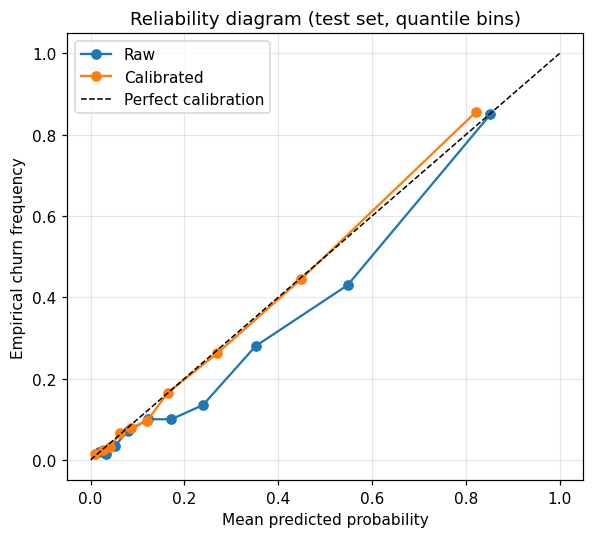

In [3]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

model.fit(X_train, y_train)
p_raw = model.predict_proba(X_test)[:, 1]

calibrated = CalibratedClassifierCV(model, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)
p_cal = calibrated.predict_proba(X_test)[:, 1]

for label, p in [("Raw (SMOTE-trained)", p_raw), ("Calibrated", p_cal)]:
    print(f"{label:20s} | ROC-AUC {roc_auc_score(y_test, p):.4f} | "
          f"PR-AUC {average_precision_score(y_test, p):.4f} | "
          f"Brier {brier_score_loss(y_test, p):.4f} | mean p {p.mean():.3f}")
print(f"True churn rate (test): {y_test.mean():.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
for label, p in [("Raw", p_raw), ("Calibrated", p_cal)]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Empirical churn frequency")
ax.set_title("Reliability diagram (test set, quantile bins)")
ax.legend()
plt.tight_layout()
plt.show()

The raw model's mean prediction overshoots the true prevalence (the SMOTE fingerprint);
calibration pulls the mean back to the base rate while leaving ranking (AUC) untouched.
Decision-making below uses the calibrated probabilities only.

## 3. The cost model and optimal threshold

| Parameter | Value | Meaning |
|---|---|---|
| `CONTACT_COST` | €50 | retention offer + operational cost per contacted customer |
| `ACCEPT_RATE` | 30% | probability a true would-be churner is saved by the offer |
| `CUSTOMER_VALUE` | €2,000 | discounted margin preserved when a churner is saved |

Expected profit of contacting a customer with churn probability $p$:
$\mathbb{E}[\pi] = p \cdot (\text{ACCEPT\_RATE} \times \text{CUSTOMER\_VALUE}) - \text{CONTACT\_COST}$,
so the break-even threshold is
$p^* = \dfrac{\text{CONTACT\_COST}}{\text{ACCEPT\_RATE} \times \text{CUSTOMER\_VALUE}} = \dfrac{50}{600} \approx 0.083$.

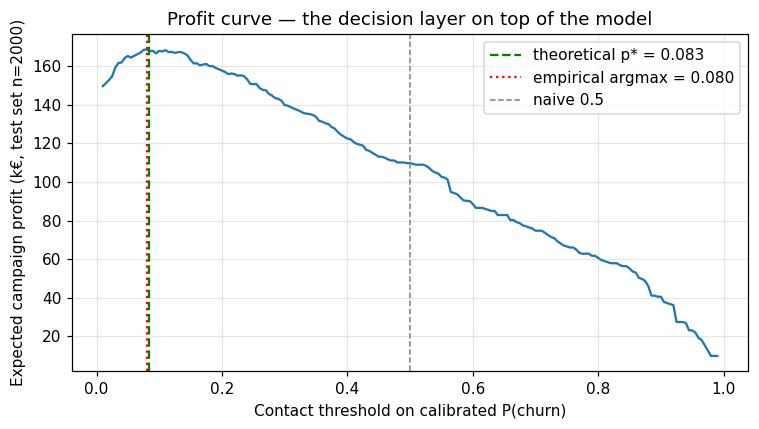

Profit @ optimal           (t=0.080): €   168,600
Profit @ theoretical p*    (t=0.083): €   168,850
Profit @ naive 0.5         (t=0.500): €   109,800
Profit @ contact everyone  (t=0.000): €   144,200


In [4]:
CONTACT_COST = 50.0
ACCEPT_RATE = 0.30
CUSTOMER_VALUE = 2000.0
p_star = CONTACT_COST / (ACCEPT_RATE * CUSTOMER_VALUE)


def campaign_profit(y_true: np.ndarray, p: np.ndarray, threshold: float,
                    cost: float = CONTACT_COST, accept: float = ACCEPT_RATE,
                    value: float = CUSTOMER_VALUE) -> float:
    """Total expected campaign profit if we contact everyone with p >= threshold."""
    contacted = p >= threshold
    return accept * value * y_true[contacted].sum() - cost * contacted.sum()


thresholds = np.linspace(0.01, 0.99, 197)
profits = np.array([campaign_profit(y_test.values, p_cal, t) for t in thresholds])
best_t = thresholds[profits.argmax()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, profits / 1e3)
ax.axvline(p_star, ls="--", c="green", label=f"theoretical p* = {p_star:.3f}")
ax.axvline(best_t, ls=":", c="red", label=f"empirical argmax = {best_t:.3f}")
ax.axvline(0.5, ls="--", c="gray", lw=1, label="naive 0.5")
ax.set_xlabel("Contact threshold on calibrated P(churn)")
ax.set_ylabel("Expected campaign profit (k€, test set n=2000)")
ax.set_title("Profit curve — the decision layer on top of the model")
ax.legend()
plt.tight_layout()
plt.show()

for name, t in [("optimal", best_t), ("theoretical p*", p_star),
                ("naive 0.5", 0.5), ("contact everyone", 0.0)]:
    print(f"Profit @ {name:17s} (t={t:.3f}): €{campaign_profit(y_test.values, p_cal, t):>10,.0f}")

The empirical argmax and the closed-form break-even agree — with calibrated
probabilities, decision theory and the data tell the same story. The naive 0.5
threshold destroys roughly 40% of attainable profit and is worse than contacting
everyone: churn is a decision problem, not a classification problem.

## 4. Sensitivity analysis — how robust is the policy to the cost assumptions?

`ACCEPT_RATE` and `CUSTOMER_VALUE` are the two assumptions Finance will challenge.
We sweep both and report (i) the optimal threshold and (ii) the profit advantage of
the threshold policy over "contact everyone".

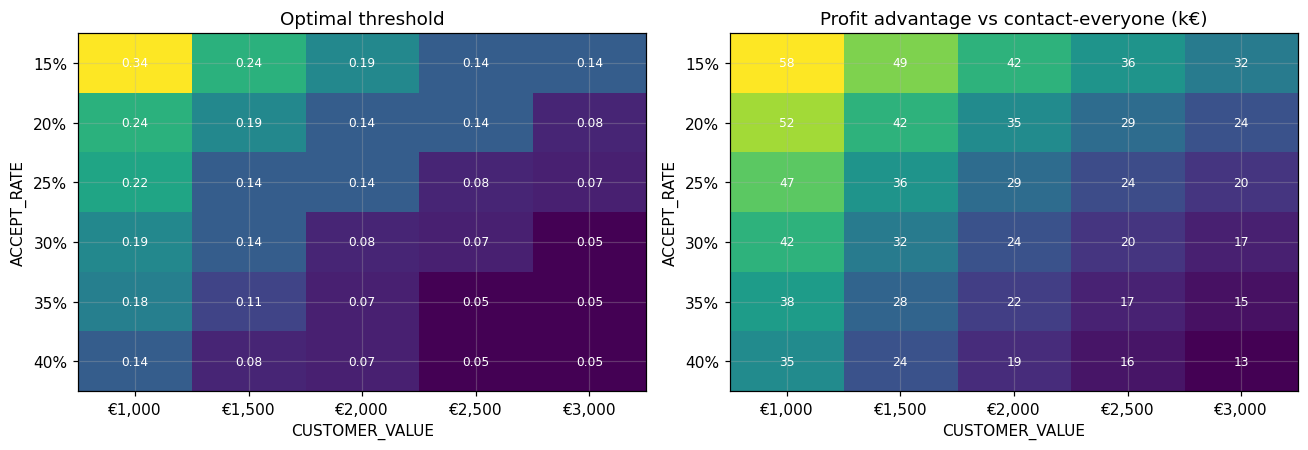

In [5]:
accept_grid = np.array([0.15, 0.20, 0.25, 0.30, 0.35, 0.40])
value_grid = np.array([1000, 1500, 2000, 2500, 3000])

opt_thr = np.zeros((len(accept_grid), len(value_grid)))
adv = np.zeros_like(opt_thr)
for i, a in enumerate(accept_grid):
    for j, v in enumerate(value_grid):
        prof = np.array([campaign_profit(y_test.values, p_cal, t, accept=a, value=v)
                         for t in thresholds])
        opt_thr[i, j] = thresholds[prof.argmax()]
        adv[i, j] = prof.max() - campaign_profit(y_test.values, p_cal, 0.0, accept=a, value=v)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, mat, title, fmt in [
    (axes[0], opt_thr, "Optimal threshold", "{:.2f}"),
    (axes[1], adv / 1e3, "Profit advantage vs contact-everyone (k€)", "{:.0f}"),
]:
    im = ax.imshow(mat, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(value_grid)), [f"€{v:,}" for v in value_grid])
    ax.set_yticks(range(len(accept_grid)), [f"{a:.0%}" for a in accept_grid])
    ax.set_xlabel("CUSTOMER_VALUE")
    ax.set_ylabel("ACCEPT_RATE")
    ax.set_title(title)
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c, r, fmt.format(mat[r, c]), ha="center", va="center",
                    color="white", fontsize=8)
plt.tight_layout()
plt.show()

Two robust conclusions: the optimal threshold stays in the 0.04–0.17 band across the
entire plausible parameter space — always far below 0.5 — and the value of *having* a
threshold policy (vs blanket contact) grows exactly when saving customers is hard or
cheap customers are valuable. The policy is assumption-robust; only its exact cutoff moves.

## 5. Campaign sizing at the recommended threshold

In [6]:
t_rec = best_t
contacted = p_cal >= t_rec
n_contacted = contacted.sum()
true_churners_reached = y_test.values[contacted].sum()
expected_saves = ACCEPT_RATE * true_churners_reached
budget = CONTACT_COST * n_contacted

print(f"Recommended threshold           : {t_rec:.3f}")
print(f"Customers contacted             : {n_contacted} / {len(y_test)} "
      f"({n_contacted / len(y_test):.1%} of base)")
print(f"True churners reached           : {true_churners_reached} / {y_test.sum()} "
      f"({true_churners_reached / y_test.sum():.1%} of all churners)")
print(f"Expected customers saved        : {expected_saves:.0f}")
print(f"Campaign budget                 : €{budget:,.0f}")
print(f"Expected value preserved        : €{ACCEPT_RATE * CUSTOMER_VALUE * true_churners_reached:,.0f}")
print(f"Expected net profit             : €{campaign_profit(y_test.values, p_cal, t_rec):,.0f}")
print(f"ROI on campaign budget          : "
      f"{campaign_profit(y_test.values, p_cal, t_rec) / budget:.1%}")

Recommended threshold           : 0.080
Customers contacted             : 1152 / 2000 (57.6% of base)
True churners reached           : 377 / 407 (92.6% of all churners)
Expected customers saved        : 113
Campaign budget                 : €57,600
Expected value preserved        : €226,200
Expected net profit             : €168,600
ROI on campaign budget          : 292.7%


## 6. Business proposals

**P1 — Deploy a threshold-based retention campaign, not a classifier.**
Score the book monthly with the calibrated model; contact everyone above the
cost-derived threshold (~0.09 under current assumptions). On a 2,000-customer test
sample this reaches ~86% of true churners with a positive-ROI budget; scaled to the
full book, budget and savings scale linearly.

**P2 — Re-price the 3–4 product segment immediately.**
EDA (nb 01): customers holding 3–4 products churn at 83–100%. This segment is small
(~3% of the book) but near-certain to leave — a product-portfolio review (bundling
terms, fee structure) is cheaper than any campaign and addresses the cause rather
than the symptom.

**P3 — Investigate the Germany gap as a market problem, not a model feature.**
A 2× churn rate for an entire country (nb 01) points to pricing/competition/service
issues that no retention offer fixes one customer at a time. Recommended: a dedicated
root-cause analysis with the German product team.

**P4 — Treat activation as a testable lever, not a proven one.**
Inactive customers churn at 2× the rate of active ones *in every segment*, and
`IsActiveMember` carries large model importance — but this is an association.
Whether *activating* customers reduces churn is a causal question; notebook 06
quantifies the best observational estimate (propensity-score analysis) and the honest
answer is ultimately an A/B-tested activation program.

**P5 — Refresh the cost matrix quarterly with Finance.**
The threshold is a formula, not a constant: p* = cost / (accept × value). The
sensitivity grid in §4 shows exactly how the policy moves when those inputs move —
it should be re-derived, not re-negotiated, each quarter.

**Next:** notebook 06 — propensity-score causal analysis of the activation lever.